In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.linalg as la

In [42]:
# nominal CoSMO parameters
n_strains = 2
n_resources = 3

c = np.zeros((n_strains,n_resources))
c[0,0] = 1
c[0,1] = 1
c[1,0] = 1
c[1,2] = 1

l = np.array([0,0.5,0.5])

w = np.array([0.5,0.5,0.5])

k = np.array([1,0,0])

r = np.array([0.1,0.1,0.1])

m = np.array([0.01,0.01])

tau = 1

B = 1/tau*m

D = np.array([2,2]) #diffusion constant for cells

H = np.array([360,160,160]) #diffusion constants for resources

CF_array = np.zeros((n_resources,n_resources)) # the MiCRM crossfeeding array (D_ab in their parlance)
CF_array[1,0] = 1
CF_array[2,0] = 1

In [3]:
def run_sim(n_strains,n_resources,c,l,w,k,r,m,tau,D,H,CF_array,N_0,R_0,dt,t_final):
    
    ratios = np.array([0.49,0.51])
    nsteps = int(t_final/dt)
    
    time = np.zeros(nsteps+1)
    
    N = np.zeros((n_strains,nsteps+1))
    N[:,0] = N_0*ratios

    R = np.zeros((n_resources,nsteps+1))
    R[0,0] = R_0
    
    for tt in range(nsteps):
        
        #I am too lazy to figure out matricies, although I'm sure that's easy
        dN = np.zeros(n_strains)
        for ii in range(n_strains):
            dN[ii] = -1/tau*N[ii,tt]*m[ii]
            for aa in range(n_resources):
                dN[ii] += 1/tau*N[ii,tt]*(1-l[aa])*w[aa]*c[ii,aa]*R[aa,tt]

        dR = np.zeros(n_resources)
        for aa in range(n_resources):
            dR[aa] = k[aa] - r[aa]*R[aa,tt]
            
            for ii in range(n_strains):
                dR[aa] += -N[ii,tt]*c[ii,aa]*R[aa,tt]
                    
                for bb in range(n_resources):
                    dR[aa] += N[ii,tt]*CF_array[aa,bb]*l[bb]*w[bb]/w[aa]*c[ii,bb]*R[bb,tt]
        
        
        N[:,tt+1] = N[:,tt] + dN*dt
        R[:,tt+1] = R[:,tt] + dR*dt
        time[tt+1] = time[tt]+dt
        
    return N,R,time

In [8]:
N_0 = 0.02
R_0 = 1
dt = 0.01
t_final = 1000

N,R,time = run_sim(n_strains,n_resources,c,l,w,k,r,m,tau,D,H,CF_array,N_0,R_0,dt,t_final)

/Users/stevenredford/opt/anaconda3/lib/python3.7/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


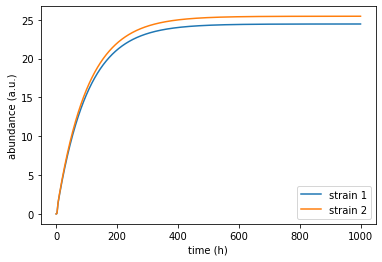

/Users/stevenredford/opt/anaconda3/lib/python3.7/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


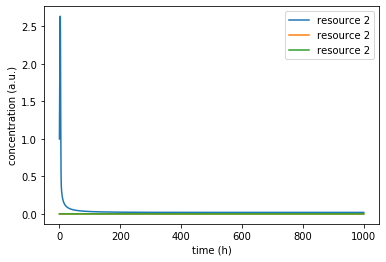

In [9]:
for nn in range(n_strains):
    plt.plot(time,N[nn,:],label='strain %s'%int(nn+1))
plt.legend()
plt.xlabel('time (h)')
plt.ylabel('abundance (a.u.)')
plt.show()

for rr in range(n_resources):
    plt.plot(time,R[rr,:],label='resource %s'%int(nn+1))
plt.legend()
plt.xlabel('time (h)')
plt.ylabel('concentration (a.u.)')
plt.show()


In [39]:
def get_steady_state(n_strains,n_resources,c,l,w,k,r,m,tau,D,H,CF_array,N_0,R_0,dt,t_final):
    
    steady_state = False
    
    attempts = 0
    
    while not steady_state:
        
        if attempts > 0:
            
            t_final = t_final*2
            print('No steady state found on attempt %s'%attempts, ' running for longer')
            
            
        epsilon = 0.001
        t_min = 10
        
        ratios = np.array([0.49,0.51])
        nsteps = int(t_final/dt)

        time = np.zeros(nsteps+1)

        N = np.zeros((n_strains,nsteps+1))
        N[:,0] = N_0*ratios

        R = np.zeros((n_resources,nsteps+1))
        R[0,0] = R_0

        for tt in range(nsteps):


            #I am too lazy to figure out matricies, although I'm sure that's easy
            dN = np.zeros(n_strains)
            for ii in range(n_strains):
                dN[ii] = -1/tau*N[ii,tt]*m[ii]
                for aa in range(n_resources):
                    dN[ii] += 1/tau*N[ii,tt]*(1-l[aa])*w[aa]*c[ii,aa]*R[aa,tt]

            dR = np.zeros(n_resources)
            for aa in range(n_resources):
                dR[aa] = k[aa] - r[aa]*R[aa,tt]

                for ii in range(n_strains):
                    dR[aa] += -N[ii,tt]*c[ii,aa]*R[aa,tt]

                    for bb in range(n_resources):
                        dR[aa] += N[ii,tt]*CF_array[aa,bb]*l[bb]*w[bb]/w[aa]*c[ii,bb]*R[bb,tt]


            N[:,tt+1] = N[:,tt] + dN*dt
            R[:,tt+1] = R[:,tt] + dR*dt
            time[tt+1] = time[tt]+dt


            if time[tt+1] > t_min and np.sum(dN) < epsilon and not steady_state:
                steady_state = True
                Nss = N[:,tt+1]
                Rss = R[:,tt+1]
                Tss = time[tt+1]
        
        attempts += 1
    
    return Nss,Rss,Tss

In [4]:
def get_A_F(n_strains, n_resources, tau,l,w,c,CF_array):
    
    # make A
    A = np.zeros((n_resources,n_strains))
    for aa in range(n_resources):
        for ii in range(n_strains):
            A[aa,ii] = tau*(1-l[aa])*w[aa]*c[ii,aa]
            
    #make F
    F = np.zeros((n_strains,n_resources,n_resources))
    for ii in range(n_strains):
        for aa in range(n_resources):
            for bb in range(n_resources):
                F[ii,aa,bb] = CF_array[aa,bb]*l[bb]*w[bb]/w[aa]*c[ii,bb]
                
    return A,F

In [5]:
def calc_T(n_strains,n_resources,Nss,Rss,A,B,D,q):
    
    T = np.zeros((n_strains,n_strains))
    
    for ii in range(n_strains):
        #this matrix is diagonal, so we only need to loop through once
        T[ii,ii] = -D[ii]*q**2 - B[ii]
        
        for bb in range(n_resources):
             T[ii,ii] += Rss[bb]*A[bb,ii]
    
    return T

In [6]:
def calc_U(n_strains,n_resources,Nss,A):
    
    U = np.zeros((n_strains,n_resources))
    for ii in range(n_strains):
        for aa in range(n_resources):
            U[ii,aa] = A[aa,ii]*Nss[ii]
            
    return U

In [7]:
def calc_V(n_strains,n_resources,Rss,F,c):
    
    V = np.zeros((n_resources,n_strains))
    for aa in range(n_resources):
        for ii in range(n_strains):
            V[aa,ii] = -c[ii,aa]*Rss[aa]
            
            for bb in range(n_resources):
                V[aa,ii] += F[ii,aa,bb]*Rss[bb]

In [9]:
def calc_W(n_strains,n_resources,Nss,F,H,r,c,q):
    
    W = np.zeros((n_resources,n_resources))
    for aa in range(n_resources):
        for bb in range(n_resources):
            if aa==bb:
                W[aa,bb] = -(q**2*H[aa] + r[aa])
            else:
                W[aa,bb]
        
            for jj in range(n_strains):

                W[aa,bb] += Nss[jj]*F[jj,aa,bb]
                
                if aa==bb:
                    
                    W[aa,bb] += -Nss[jj]*c[jj,aa]
    
    return W

In [ ]:
# as U and V do not depend on q, we will pre-compute them for every steady state
A,F = get_A_F(n_strains, n_resources, tau,l,w,c,CF_array)

U = calc_U(n_strains,n_resources,Nss,A)
V = calc_V(n_strains,n_resources,Rss,F,c)

In [ ]:
def build_big_matrix(n_strains,n_resources,Nss,Rss,A,B,D,F,H,r,c,q):
    
    M = np.zeros((int(n_strains+n_resources),int(n_strains+n_resources)))
    
    T = calc_T(n_strains,n_resources,Nss,Rss,A,B,D,q)
    W = calc_W(n_strains,n_resources,Nss,F,H,r,c,q)
    
    M[0:n_strains,0:n_strains] = T
    M[0:n_strains,n_strains:] = U
    M[n_strains:,0:n_strains] = V
    M[n_strains:,n_strains:] = W
    
    return M

In [5]:
#tester 
M = np.array([(1,0,0.7),(0,0.6,0),(0.8,1.2,2)])

vals,vecs = la.eig(M)

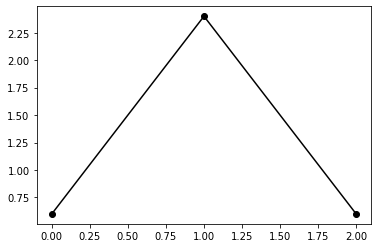

In [7]:
plt.plot(vals,'k-o')
plt.show()

In [40]:
"""
#troubleshooting for the steady state function

N_0 = 0.02
R_0 = 1
dt = 0.01
t_final = 100

N,R,time,Nss,Rss,Tss = get_steady_state(n_strains,n_resources,c,l,w,k,r,m,tau,D,H,CF_array,N_0,R_0,dt,t_final)


for nn in range(n_strains):
    plt.plot(time,N[nn,:],label='strain %s'%int(nn+1))
    plt.axhline(y=Nss[nn])
plt.legend()
plt.axvline(x=Tss)
plt.xlabel('time (h)')
plt.ylabel('abundance (a.u.)')
plt.show()

for rr in range(n_resources):
    plt.plot(time,R[rr,:],label='resource %s'%int(nn+1))
plt.legend()
plt.xlabel('time (h)')
plt.ylabel('concentration (a.u.)')
plt.show()

"""

No steady state found on attempt 1  running for longer
No steady state found on attempt 2  running for longer
No steady state found on attempt 3  running for longer
